# Early Warning parameter estimation

In [1]:
import warnings 
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import GWFish.modules as gw
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
import corner
import numpy as np
import pandas as pd
import json
import os
from astropy.cosmology import Planck18

In [2]:

parameters = {
    'chirp_mass': np.array([1.1858999987203738]) * (1 + 0.00980), 
    'mass_ratio': np.array([0.8308538032620448]), 
    'luminosity_distance': Planck18.luminosity_distance(0.00980).value,
    'theta_jn': np.array([2.545065595974997]),
    'ra': np.array([3.4461599999999994]),
    'dec': np.array([-0.4080839999999999]),
    'psi': np.array([0.]),
    'phase': np.array([0.]),
    'geocent_time': np.array([1187008882.4]),
    'a_1':np.array([0.005136138323169717]), 
    'a_2':np.array([0.003235146993487445]), 
    'lambda_1':np.array([368.17802383555687]), 
    'lambda_2':np.array([586.5487031450857])}
parameters = pd.DataFrame(parameters)
parameters

,chirp_mass,mass_ratio,luminosity_distance,theta_jn,ra,dec,psi,phase,geocent_time,a_1,a_2,lambda_1,lambda_2
0,1.197522,0.830854,43.747554,2.545066,3.44616,-0.408084,0.0,0.0,1.187009e+09,0.005136,0.003235,368.178024,586.548703


GPS:  1187008882.4
UTC:  2017-08-17 12:41:04.400
GMST: 156.356 deg

  Detector                       Fp        Fc     Fp2+Fc2
  -------------------------------------------------------
  LIGO Livingston (LLO)      0.1320   -0.7395      0.5643
  LIGO Hanford (LHO)         0.0785    0.8859      0.7910
  Virgo                     -0.1601    0.2577      0.0921


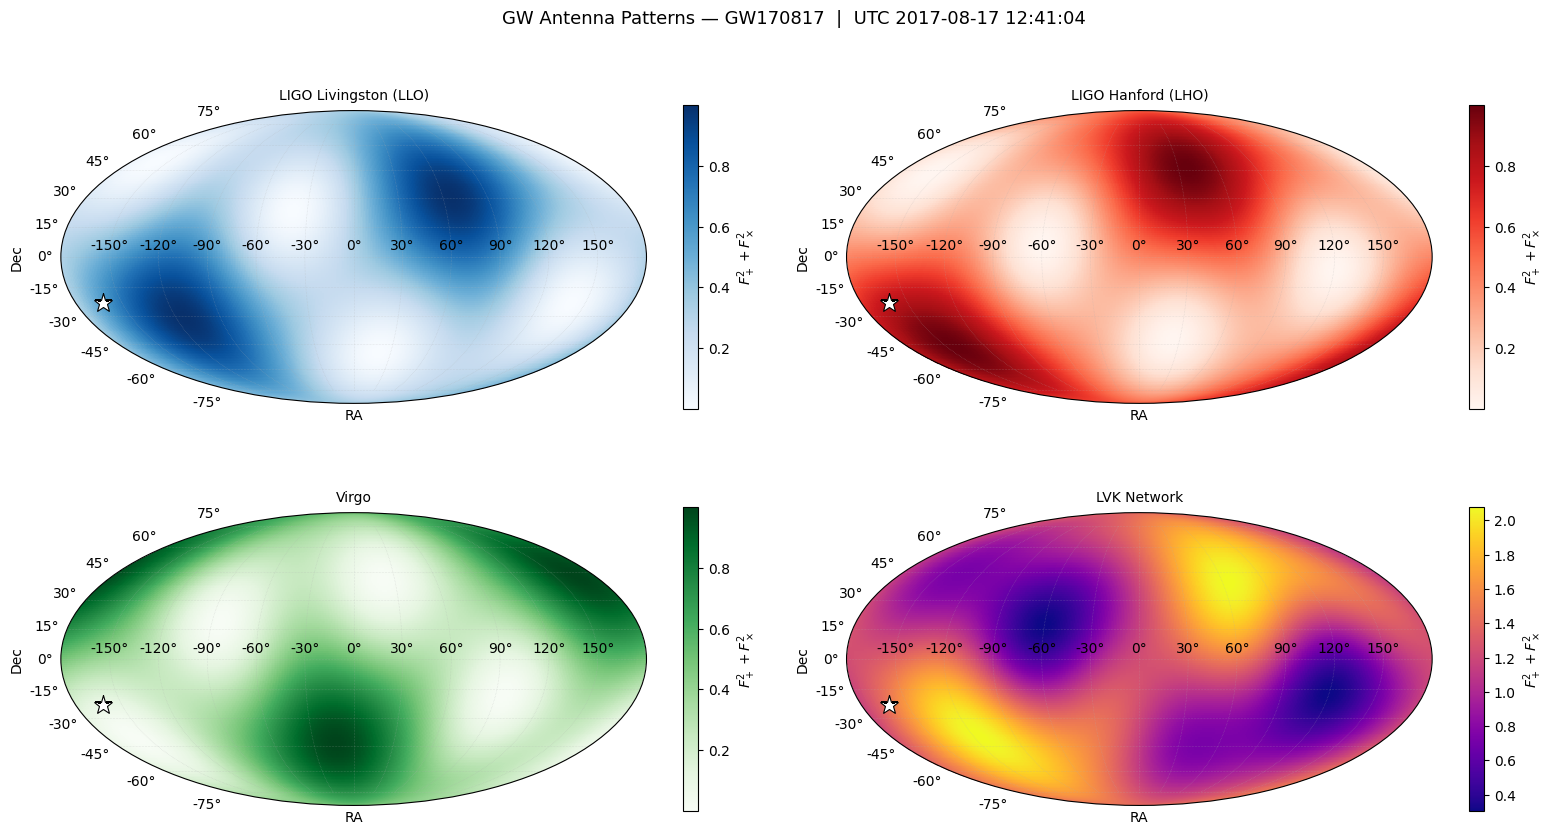

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time

# ── Configuration ──────────────────────────────────────────────────
GPS_TRIGGER = 1187008882.4
ra_src_deg  = 197.5
dec_src_deg = -23.4

ra_src      = np.radians(ra_src_deg)
dec_src     = np.radians(dec_src_deg)

# ra_src is in radians [0, 2π]. Mollweide expects [-π, π].
ra_plot = ra_src - 2*np.pi if ra_src > np.pi else ra_src


DETECTORS_ECEF = {
    'LIGO Livingston (LLO)': {
        'arm1': np.array([-0.95457412153, -0.14158077340, -0.26218911324]),
        'arm2': np.array([ 0.29774156894, -0.48791033647, -0.82054461286]),
        'cmap': 'Blues',
    },
    'LIGO Hanford (LHO)': {
        'arm1': np.array([-0.22389266154,  0.79983062746,  0.55690487831]),
        'arm2': np.array([-0.91397818574,  0.02609403989, -0.40492342125]),
        'cmap': 'Reds',
    },
    'Virgo': {
        'arm1': np.array([-0.70045821479,  0.20848948619,  0.68256166277]),
        'arm2': np.array([-0.05379255368, -0.96908180549,  0.24080451708]),
        'cmap': 'Greens',
    },
}

# ── Functions ──────────────────────────────────────────────────────
def get_gmst(gps_time):
    t = Time(gps_time, format='gps', scale='utc')
    return t.sidereal_time('mean', 'greenwich').rad

def compute_Fp_Fc(arm1, arm2, ra, dec, gmst, psi=0.0):
    theta = np.pi/2 - dec
    phi   = ra
    m_eq = np.array([-np.sin(phi),  np.cos(phi), 0.0])
    n_eq = np.array([-np.cos(theta)*np.cos(phi),
                     -np.cos(theta)*np.sin(phi),
                      np.sin(theta)])
    c, s  = np.cos(gmst), np.sin(gmst)
    R     = np.array([[c, s, 0], [-s, c, 0], [0, 0, 1]])
    m     = R @ m_eq
    n     = R @ n_eq
    m_rot =  np.cos(2*psi)*m + np.sin(2*psi)*n
    n_rot = -np.sin(2*psi)*m + np.cos(2*psi)*n
    e_p   = np.outer(m_rot, m_rot) - np.outer(n_rot, n_rot)
    e_c   = np.outer(m_rot, n_rot) + np.outer(n_rot, m_rot)
    D     = 0.5 * (np.outer(arm1, arm1) - np.outer(arm2, arm2))
    return np.tensordot(D, e_p, axes=2), np.tensordot(D, e_c, axes=2)

def antenna_power(arm1, arm2, ra, dec, gmst):
    Fp, Fc = compute_Fp_Fc(arm1, arm2, ra, dec, gmst)  
    return Fp**2 + Fc**2

# ── Sky grid ───────────────────────────────────────────────────────
n_ra, n_dec = 360, 180
ra_grid     = np.linspace(-np.pi, np.pi, n_ra)
dec_grid    = np.linspace(-np.pi/2, np.pi/2, n_dec)
RA, DEC     = np.meshgrid(ra_grid, dec_grid)
ra_flat     = RA.flatten()
dec_flat    = DEC.flatten()

gmst  = get_gmst(GPS_TRIGGER)
t_utc = Time(GPS_TRIGGER, format='gps', scale='utc').iso
print(f"GPS:  {GPS_TRIGGER}\nUTC:  {t_utc}\nGMST: {np.degrees(gmst):.3f} deg\n")

# ── Compute maps ───────────────────────────────────────────────────
powers = {}
for name, cfg in DETECTORS_ECEF.items():
    p = np.array([
        antenna_power(cfg['arm1'], cfg['arm2'], ra, dec, gmst)
        for ra, dec in zip(ra_flat, dec_flat)
    ]).reshape(n_dec, n_ra)
    powers[name] = p

power_network = sum(powers.values())

# ── Print antenna factors at source ───────────────────────────────
print(f"  {'Detector':<23}  {'Fp':>8}  {'Fc':>8}  {'Fp2+Fc2':>10}")
print("  " + "-"*55)
for name, cfg in DETECTORS_ECEF.items():
    Fp, Fc = compute_Fp_Fc(cfg['arm1'], cfg['arm2'], ra_src, dec_src, gmst)
    print(f"  {name:<23}  {Fp:>8.4f}  {Fc:>8.4f}  {Fp**2+Fc**2:>10.4f}")

# ── Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9), subplot_kw={'projection': 'mollweide'})
plot_data = [
    (powers['LIGO Livingston (LLO)'], 'LIGO Livingston (LLO)', 'Blues'),
    (powers['LIGO Hanford (LHO)'],    'LIGO Hanford (LHO)',    'Reds'),
    (powers['Virgo'],                 'Virgo',                 'Greens'),
    (power_network,                   'LVK Network',           'plasma'),
]
for ax, (power, title, cmap) in zip(axes.flatten(), plot_data):
    im = ax.pcolormesh(ra_grid, dec_grid, power, cmap=cmap, shading='auto')
    # ...)   # CORRECT

    ax.plot(ra_plot, dec_src, 'w*', markersize=14,
            markeredgecolor='black', markeredgewidth=0.8, zorder=5)
    ax.grid(True, linestyle='dotted', linewidth=0.4, alpha=0.5)
    ax.set_title(title, fontsize=10, pad=8)
    plt.colorbar(im, ax=ax, shrink=0.7, label=r'$F_+^2 + F_\times^2$')
    ax.set_xlabel('RA')
    ax.set_ylabel('Dec')

plt.suptitle(f'GW Antenna Patterns — GW170817  |  UTC {t_utc[:19]}', fontsize=13)
plt.tight_layout()
plt.savefig('antenna_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# We choose a waveform approximant suitable for BNS analysis
# In this case we are taking into account tidal polarizability effects
waveform_model = 'IMRPhenomD_NRTidalv2'
f_ref = 10.

### ⚠️ Note:
> The default reference frequency `f_ref` is set to $10$, the user can pass a different value, together with the `waveform_model` parameter (see examples below)


## Play with the signal

In [8]:
# Choose the detector onto which you want to project the signal
detector = 'LLO'

# The following function outputs the signal projected onto the chosen detector
signal, _ = gw.utilities.get_fd_signal(parameters, detector, waveform_model, f_ref) # waveform_model and f_ref are passed together
frequency = gw.detection.Detector(detector).frequencyvector[:, 0]
# add the detector's sensitivity curve and plot the characteristic strain
psd_data = gw.utilities.get_detector_psd(detector)
# psd_data is a dictionary with the keys 'frequency' and 'psd'

plt.loglog(frequency, 2 * frequency * np.abs(signal[:, 0]), label='%s' %waveform_model)
plt.loglog(psd_data[:, 0], np.sqrt(psd_data[:, 0] * psd_data[:, 1]), label='%s sensitivity' %detector, color='green')
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain')
plt.grid(linestyle='dotted', linewidth='0.6', which='both')
plt.title('Projected signal on %s' %detector)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/opt/anaconda3/envs/acme_env/lib/python3.10/site-packages/GWFish/detector_psd/LLO_psd.txt'

In [6]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from astropy.time import Time
import GWFish.modules.detection as det
import GWFish.modules.waveforms as wf

# ── Source parameters ─────────────────────────────────────────────
GPS_TRIGGER = 1187008882.4
ra_src      = np.radians(197.5)
dec_src     = np.radians(-23.4)

parameters = pd.DataFrame({
    'mass_1':              [1.46],
    'mass_2':              [1.27],
    'luminosity_distance': [40.0],
    'theta_jn':            [2.545],
    'ra':                  [float(ra_src)],
    'dec':                 [float(dec_src)],
    'psi':                 [0.0],
    'phase':               [0.0],
    'geocent_time':        [float(GPS_TRIGGER)],
    'a_1':                 [0.0],
    'a_2':                 [0.0],
})

waveform_model = 'TaylorF2'
f_min = 23.0   # GW170817 entered band at ~24 Hz
f_max = 2e3
PUBLISHED_SNR = {'LLO': 26.4, 'LHO': 18.8, 'VIR': 2.0}

# ── ECEF arm unit vectors (official LAL values) ───────────────────
ARMS = {
    'LLO': {
        'arm1': np.array([-0.95457412153, -0.14158077340, -0.26218911324]),
        'arm2': np.array([ 0.29774156894, -0.48791033647, -0.82054461286]),
    },
    'LHO': {
        'arm1': np.array([-0.22389266154,  0.79983062746,  0.55690487831]),
        'arm2': np.array([-0.91397818574,  0.02609403989, -0.40492342125]),
    },
    'VIR': {
        'arm1': np.array([-0.70045821479,  0.20848948619,  0.68256166277]),
        'arm2': np.array([-0.05379255368, -0.96908180549,  0.24080451708]),
    },
}

# ── Antenna pattern functions ─────────────────────────────────────
def get_gmst(gps_time):
    return Time(gps_time, format='gps', scale='utc').sidereal_time('mean', 'greenwich').rad

def compute_Fp_Fc(arm1, arm2, ra, dec, gmst, psi=0.0):
    theta = np.pi/2 - dec
    phi   = ra
    m_eq  = np.array([-np.sin(phi), np.cos(phi), 0.0])
    n_eq  = np.array([-np.cos(theta)*np.cos(phi),
                      -np.cos(theta)*np.sin(phi),
                       np.sin(theta)])
    c, s  = np.cos(gmst), np.sin(gmst)
    R     = np.array([[c, s, 0], [-s, c, 0], [0, 0, 1]])
    m     = R @ m_eq;  n = R @ n_eq
    m_rot =  np.cos(2*psi)*m + np.sin(2*psi)*n
    n_rot = -np.sin(2*psi)*m + np.cos(2*psi)*n
    e_p   = np.outer(m_rot, m_rot) - np.outer(n_rot, n_rot)
    e_c   = np.outer(m_rot, n_rot) + np.outer(n_rot, m_rot)
    D     = 0.5*(np.outer(arm1, arm1) - np.outer(arm2, arm2))
    return np.tensordot(D, e_p, axes=2), np.tensordot(D, e_c, axes=2)

gmst = get_gmst(GPS_TRIGGER)
psi  = float(parameters['psi'].iloc[0])

# ── Signal helper ─────────────────────────────────────────────────
def get_signal(gwname, params_df, model):
    detector    = det.Detector(gwname)
    freq        = detector.frequencyvector[:, 0]
    data_params = {'frequencyvector': detector.frequencyvector, 'f_ref': 50.0}
    wav_obj     = wf.TaylorF2(model, params_df, data_params)
    wav_obj.gw_params = {k: float(v.iloc[0]) if hasattr(v, 'iloc') else float(v)
                         for k, v in wav_obj.gw_params.items()}
    return freq, wav_obj()

# ── Compute projected SNR ─────────────────────────────────────────
print(f"  {'Det':<5}  {'Fp':>7}  {'Fc':>7}  {'Fp2+Fc2':>9}  "
      f"{'SNR (proj)':>11}  {'Published':>10}")
print("  " + "-"*60)

total_snr_sq = 0.0

for gwname in ['LLO', 'LHO', 'VIR']:
    freq, hf = get_signal(gwname, parameters, waveform_model)
    psd      = det.Detector(gwname).components[0].psd_data

    # Antenna factors at source position
    Fp, Fc = compute_Fp_Fc(
        ARMS[gwname]['arm1'], ARMS[gwname]['arm2'],
        float(ra_src), float(dec_src), gmst, psi
    )

    # Mask to [f_min, f_max]
    ms = (freq >= f_min) & (freq <= f_max)
    f  = freq[ms]
    hp = hf[ms, 0]
    hc = hf[ms, 1]

    # Projected strain: h_det = F+ h+ + Fc hx
    h_det = Fp * hp + Fc * hc

    # Interpolate PSD
    Sn = interp1d(psd[:, 0], psd[:, 1],
                  bounds_error=False, fill_value=np.inf)(f)

    # df
    df = np.diff(f); df = np.append(df, df[-1])

    # ρ² = 4 ∫ |F+ h+ + Fc hx|² / Sn df
    snr_sq = 4.0 * np.nansum(np.abs(h_det)**2 / Sn * df)
    snr    = np.sqrt(snr_sq)
    total_snr_sq += snr_sq

    print(f"  {gwname:<5}  {Fp:>7.4f}  {Fc:>7.4f}  "
          f"{Fp**2+Fc**2:>9.4f}  {snr:>11.1f}  "
          f"{PUBLISHED_SNR[gwname]:>10.1f}")

print(f"\n  Network SNR: {np.sqrt(total_snr_sq):.1f}   [published: 32.4]")

  Det         Fp       Fc    Fp2+Fc2   SNR (proj)   Published
  ------------------------------------------------------------
  LLO     0.1320  -0.7395     0.5643         93.1        26.4
  LHO     0.0785   0.8859     0.7910        109.9        18.8
  VIR    -0.1601   0.2577     0.0921         29.4         2.0

  Network SNR: 147.0   [published: 32.4]


In [7]:
# suppress warning outputs for using lal in jupuyter notebook
import warnings 
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import GWFish.modules as gw
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
import corner
import numpy as np
import pandas as pd
import json
import os
from astropy.cosmology import Planck18

In [8]:
# Event's parameters should be passed as Pandas dataframe

parameters = {
    'chirp_mass': np.array([1.1858999987203738]) * (1 + 0.00980), 
    'mass_ratio': np.array([0.8308538032620448]), 
    'luminosity_distance': Planck18.luminosity_distance(0.00980).value,
    'theta_jn': np.array([2.545065595974997]),
    'ra': np.array([3.4461599999999994]),
    'dec': np.array([-0.4080839999999999]),
    'psi': np.array([0.]),
    'phase': np.array([0.]),
    'geocent_time': np.array([1187008882.4]),
    'a_1':np.array([0.005136138323169717]), 
    'a_2':np.array([0.003235146993487445]), 
    'lambda_1':np.array([368.17802383555687]), 
    'lambda_2':np.array([586.5487031450857])}
parameters = pd.DataFrame(parameters)
parameters

,chirp_mass,mass_ratio,luminosity_distance,theta_jn,ra,dec,psi,phase,geocent_time,a_1,a_2,lambda_1,lambda_2
0,1.197522,0.830854,43.747554,2.545066,3.44616,-0.408084,0.0,0.0,1.187009e+09,0.005136,0.003235,368.178024,586.548703


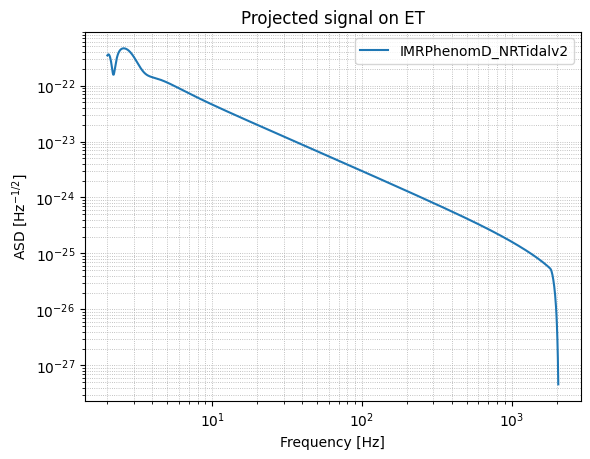

In [9]:
# We choose a waveform approximant suitable for BNS analysis
# In this case we are taking into account tidal polarizability effects
waveform_model = 'IMRPhenomD_NRTidalv2'
f_ref = 10.
# Choose the detector onto which you want to project the signal
detector = 'ET'

# The following function outputs the signal projected onto the chosen detector
signal, _ = gw.utilities.get_fd_signal(parameters, detector, waveform_model, f_ref) # waveform_model and f_ref are passed together
frequency = gw.detection.Detector(detector).frequencyvector[:, 0]
# This signal has three components since ET comprises three detectors, let's plot one of them
plt.loglog(frequency, np.abs(signal[:, 0]), label='%s' %waveform_model)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('ASD [Hz$^{-1/2}$]')
plt.grid(linestyle='dotted', linewidth='0.6', which='both')
plt.title('Projected signal on %s' %detector)
plt.show()

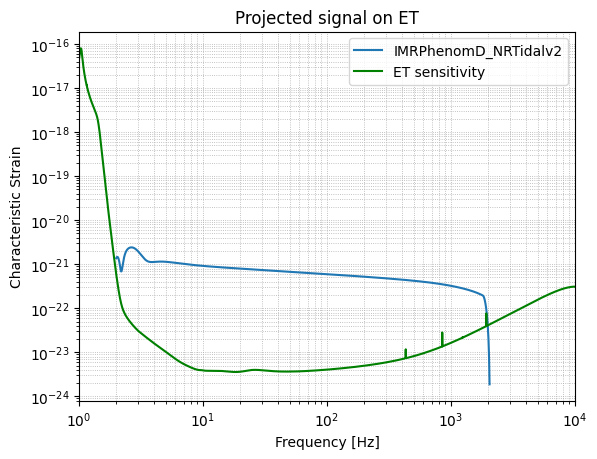

In [10]:

# Choose the detector onto which you want to project the signal
detector = 'ET'

# The following function outputs the signal projected onto the chosen detector
signal, _ = gw.utilities.get_fd_signal(parameters, detector, waveform_model, f_ref) # waveform_model and f_ref are passed together
frequency = gw.detection.Detector(detector).frequencyvector[:, 0]
# This signal has three components since ET comprises three detectors, let's plot one of them

# add the detector's sensitivity curve and plot the characteristic strain
psd_data = gw.utilities.get_detector_psd(detector)
# psd_data is a dictionary with the keys 'frequency' and 'psd'

plt.loglog(frequency, 2 * frequency * np.abs(signal[:, 0]), label='%s' %waveform_model)
plt.loglog(psd_data[:, 0], np.sqrt(psd_data[:, 0] * psd_data[:, 1]), label='%s sensitivity' %detector, color='green')
plt.xlim(1, 1e4)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain')
plt.grid(linestyle='dotted', linewidth='0.6', which='both')
plt.title('Projected signal on %s' %detector)
plt.show()

In [11]:
# ── Get PSDs ──────────────────────────────────────────────────────────────────
psd_ET      = gw.utilities.get_detector_psd('ET')
psd_LIGO_O5 = gw.utilities.get_detector_psd('LIGO_O5')
psd_Virgo_O5 = gw.utilities.get_detector_psd('Virgo_O5')

# ── Get LLO signal and frequency ──────────────────────────────────────────────
signal_LLO, _ = gw.utilities.get_fd_signal(parameters, 'LLO', waveform_model, f_ref)
frequency_LLO  = gw.detection.Detector('LLO').frequencyvector[:, 0]

# Check antenna pattern factors for each detector
for det_name in ['ET', 'LLO', 'LHO']:
    det = gw.detection.Detector(det_name)
    # Fp, Fc are the plus and cross antenna pattern functions
    print(f"\n{det_name}:")
    print(f"  location: {det.location}")
    
    # The effective amplitude factor ~ sqrt(Fp^2 + Fc^2)
    # You can extract it from the signal ratio
    
sig_ET_amp  = np.median(np.abs(signal[:, 0]))
sig_LLO_amp = np.median(np.abs(signal_LLO[:, 0]))
print(f"\nMedian |h| ratio  LLO/ET = {sig_LLO_amp/sig_ET_amp:.3f}")

# Compare all three ET arms vs LLO
for i in range(3):
    amp = np.median(np.abs(signal[:, i]))
    print(f"ET arm {i}: median |h| = {amp:.3e}")

print(f"LLO:       median |h| = {sig_LLO_amp:.3e}")


ET:
  location: earth

LLO:
  location: earth

LHO:
  location: earth

Median |h| ratio  LLO/ET = 0.863
ET arm 0: median |h| = 5.049e-24
ET arm 1: median |h| = 4.263e-24
ET arm 2: median |h| = 6.341e-24
LLO:       median |h| = 4.357e-24


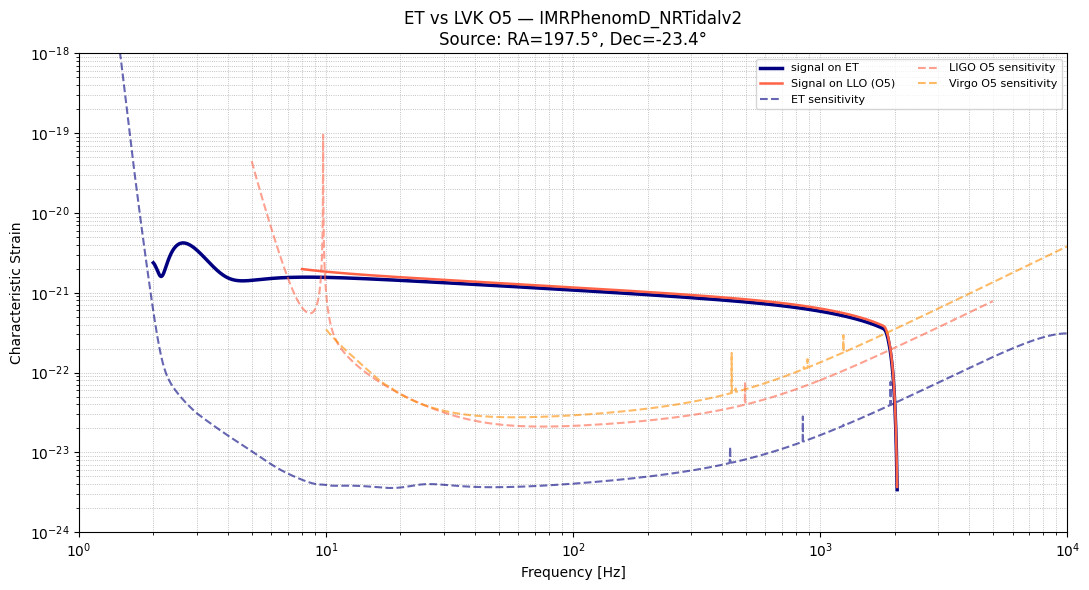

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))

# ── All 3 ET arms ─────────────────────────────────────────────────────────────
et_colors = ['steelblue', 'cornflowerblue', 'royalblue']
#for i, col in enumerate(et_colors):
#    ax.loglog(frequency, 2 * frequency * np.abs(signal[:, i]),
#              color=col, lw=1.5, alpha=0.8, label=f'ET arm {i}')

# ── ET combined (quadrature sum of all 3 arms) ────────────────────────────────
signal_ET_combined = np.sqrt(np.sum(np.abs(signal)**2, axis=1))
ax.loglog(frequency, 2 * frequency * signal_ET_combined,
          color='navy', lw=2.5, label='signal on ET')

# ── LVK signals ───────────────────────────────────────────────────────────────
ax.loglog(frequency_LLO, 2 * frequency_LLO * np.abs(signal_LLO[:, 0]),
          color='tomato', lw=1.8, label='Signal on LLO (O5)')

# ── Sensitivity curves ────────────────────────────────────────────────────────
ax.loglog(psd_ET[:, 0],       np.sqrt(psd_ET[:, 0]       * psd_ET[:, 1]),
          color='navy',       lw=1.5, linestyle='--', alpha=0.6,
          label='ET sensitivity')
ax.loglog(psd_LIGO_O5[:, 0],  np.sqrt(psd_LIGO_O5[:, 0]  * psd_LIGO_O5[:, 1]),
          color='tomato',     lw=1.5, linestyle='--', alpha=0.6,
          label='LIGO O5 sensitivity')
ax.loglog(psd_Virgo_O5[:, 0], np.sqrt(psd_Virgo_O5[:, 0] * psd_Virgo_O5[:, 1]),
          color='darkorange', lw=1.5, linestyle='--', alpha=0.6,
          label='Virgo O5 sensitivity')

# ── Annotation explaining the ratio ──────────────────────────────────────────
#ax.text(0.02, 0.05,
#        f'LLO/ET arm0 amplitude ratio = {sig_LLO_amp/sig_ET_amp:.2f}×\n'
#        f'(antenna pattern effect for this sky position)',
#        transform=ax.transAxes, fontsize=8,
#        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic Strain')
ax.grid(linestyle='dotted', linewidth=0.6, which='both')
ax.legend(fontsize=8, ncol=2)
ax.set_title(f'ET vs LVK O5 — {waveform_model}\n'
             f'Source: RA={np.degrees(parameters["ra"].iloc[0]):.1f}°, '
             f'Dec={np.degrees(parameters["dec"].iloc[0]):.1f}°')

plt.xlim(1, 1e4)
plt.ylim(1e-24, 1e-18)

plt.tight_layout()
plt.savefig('ET_vs_O5_strain_alarms.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Plot the time before the merger as a function of the frequency
_, t_of_f = gw.utilities.get_fd_signal(parameters, detector, waveform_model, f_ref)

# The networks are the combinations of detectors that will be used for the analysis
# The detection_SNR is the minimum SNR for a detection:
#   --> The first entry specifies the minimum SNR for a detection in a single detector
#   --> The second entry specifies the minimum network SNR for a detection
detectors = ['ET', 'CE1', 'LLO', 'LHO', 'VIR']
network = gw.detection.Network(detector_ids = detectors, detection_SNR = (0., 8.))
snr = gw.utilities.get_snr(parameters, network, waveform_model, f_ref)


In [14]:
snr

,ET,CE1,LLO,LHO,VIR,network
event_0,645.005406,1126.071931,85.542104,101.09583,27.422189,1304.745095


In [15]:
# The fisher parameters are the parameters that will be used to calculate the Fisher matrix
# and on which we will calculate the errors
fisher_parameters = ['chirp_mass', 'mass_ratio', 'luminosity_distance', 'theta_jn', 'dec','ra',
                     'psi', 'phase', 'geocent_time', 'a_1', 'a_2', 'lambda_1', 'lambda_2']

In [16]:
detected, network_snr, parameter_errors, sky_localization = gw.fishermatrix.compute_network_errors(
        network = gw.detection.Network(detector_ids = ['ET'], detection_SNR = (0., 8.)),
        parameter_values = parameters,
        fisher_parameters=fisher_parameters, 
        waveform_model = waveform_model,
        f_ref = 20.,
        )   
        # use_duty_cycle = False, # default is False anyway
        # save_matrices = False, # default is False anyway, put True if you want Fisher and covariance matrices in the output
        # save_matrices_path = None, # default is None anyway,
                                     # otherwise specify the folder
                                     # where to save the Fisher and
                                     # corresponding covariance matrices
    


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.65s/it]


In [17]:
# Choose percentile factor of sky localization and pass from rad2 to deg2
percentile = 90.
sky_localization_90cl = sky_localization * gw.fishermatrix.sky_localization_percentile_factor(percentile)
sky_localization_90cl


# One can create a dictionary with the parameter errors, the order is the same as the one given in fisher_parameters
parameter_errors_dict = {}
for i, parameter in enumerate(fisher_parameters):
    parameter_errors_dict['err_' + parameter] = np.squeeze(parameter_errors)[i]

print('The parameter errors of the event are ')
parameter_errors_dict

The parameter errors of the event are 


{'err_chirp_mass': 7.72779259248137e-07,
 'err_mass_ratio': 0.01245775908412383,
 'err_luminosity_distance': 2.2517124277186706,
 'err_theta_jn': 0.07997824018450687,
 'err_dec': 0.0036304735517044655,
 'err_ra': 0.0045523597105015,
 'err_psi': 0.1233473110882511,
 'err_phase': 0.2484025786007817,
 'err_geocent_time': 9.925364350300389e-05,
 'err_a_1': 0.1748813495349503,
 'err_a_2': 0.21748881165393194,
 'err_lambda_1': 2559.072176161789,
 'err_lambda_2': 4614.122796339818}

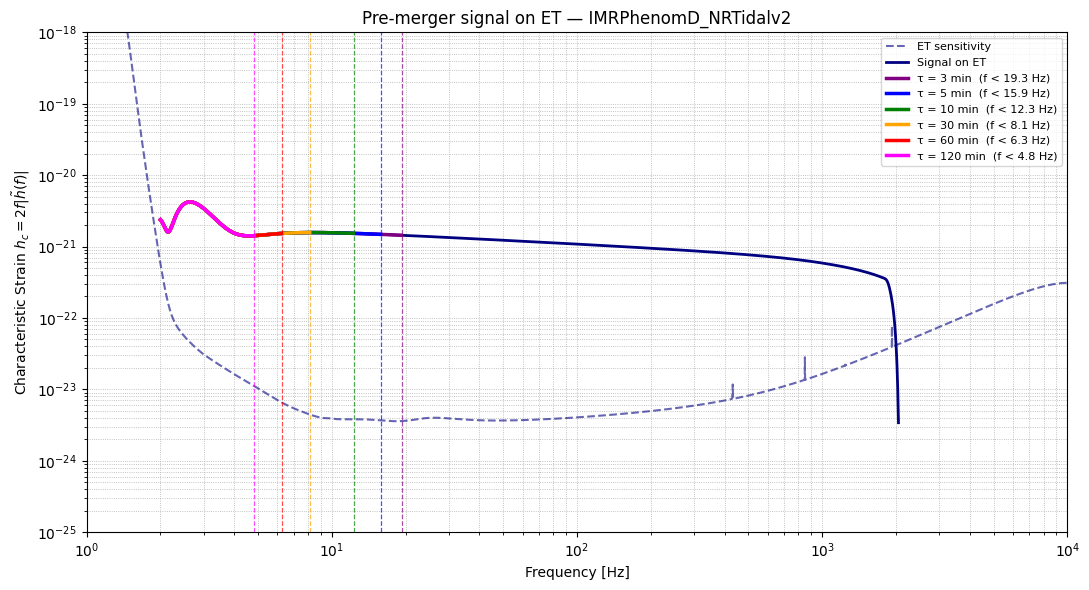

In [18]:
M_sun = 1.989e30
G     = 6.674e-11
c     = 3e8

params_row = parameters.iloc[0]
Mc_solar   = params_row['chirp_mass']
Mc_sec     = Mc_solar * M_sun * G / c**3

# ── Multiple pre-merger times ─────────────────────────────────────────────────
tau_minutes_list = [3, 5, 10, 30, 60, 120]   # minutes before merger
colors_tau       = ['purple', 'blue', 'green', 'orange', 'red', 'magenta']

# ── ET combined signal ────────────────────────────────────────────────────────
signal_ET_combined = np.sqrt(np.sum(np.abs(signal)**2, axis=1))
signal_ET          = 2 * frequency * signal_ET_combined

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(11, 6))

# Sensitivity curve
plt.loglog(psd_ET[:, 0], np.sqrt(psd_ET[:, 0] * psd_ET[:, 1]),
           color='navy', lw=1.5, linestyle='--', alpha=0.6,
           label='ET sensitivity')

# Full signal
plt.loglog(frequency, signal_ET, color='navy', lw=2, label='Signal on ET')

# Pre-merger cuts
for tau_min, col in zip(tau_minutes_list, colors_tau):
    tau_sec = tau_min * 60
    f_cut   = (1/np.pi) * (5 / (256 * Mc_sec**(5/3) * tau_sec))**(3/8)

    # Highlight the pre-merger portion
    mask = frequency <= f_cut
    if mask.any():
        plt.loglog(frequency[mask], signal_ET[mask],
                   color=col, lw=2.5,
                   label=f'τ = {tau_min} min  (f < {f_cut:.1f} Hz)')
        plt.axvline(f_cut, color=col, linestyle='--', lw=0.9, alpha=0.7)

plt.xlim(1, 1e4)
plt.ylim(1e-25, 1e-18)
plt.legend(fontsize=8, loc='upper right')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain $h_c = 2f|\\tilde{h}(f)|$')
plt.grid(linestyle='dotted', linewidth=0.6, which='both')
plt.title(f'Pre-merger signal on ET — {waveform_model}')
plt.tight_layout()
plt.show()

In [19]:
# create forlder where store results
!mkdir tutorial_results

data_folder = 'tutorial_results' # the one we just created
network = gw.detection.Network(detector_ids = ['ET'], detection_SNR = (0., 8.))
gw.fishermatrix.analyze_and_save_to_txt(network = network,
                                        parameter_values  = parameters,
                                        fisher_parameters = fisher_parameters, 
                                        sub_network_ids_list = [[0]],
                                        population_name = 'BNS',
                                        waveform_model = waveform_model,
                                        f_ref = 20.,
                                        save_path = data_folder,
                                        save_matrices = True)

mkdir: cannot create directory ‘tutorial_results’: File exists


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.91s/it]


In [20]:
fisher_matrix = np.load(data_folder + '/' + 'fisher_matrices_ET_BNS_SNR8.npy')
errors = pd.read_csv(data_folder + '/' + 'Errors_ET_BNS_SNR8.txt', delimiter = ' ')

# One can access all the column names of the errors output file:
errors.keys()

Index(['network_SNR', 'chirp_mass', 'mass_ratio', 'luminosity_distance',
       'theta_jn', 'ra', 'dec', 'psi', 'phase', 'geocent_time', 'a_1', 'a_2',
       'lambda_1', 'lambda_2', 'err_chirp_mass', 'err_mass_ratio',
       'err_luminosity_distance', 'err_theta_jn', 'err_dec', 'err_ra',
       'err_psi', 'err_phase', 'err_geocent_time', 'err_a_1', 'err_a_2',
       'err_lambda_1', 'err_lambda_2', 'err_sky_location'],
      dtype='object')

Original: 2.00 → 2048.00 Hz, 1000 pts
tau=   1 min → f_cut=29.06 Hz (386 pts)

100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.73s/it]


 → ΔΩ = 0.17 deg²
tau=  10 min → f_cut=12.26 Hz (262 pts)

100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.21s/it]


 → ΔΩ = 0.20 deg²
tau=  30 min → f_cut=8.12 Hz (202 pts)

...

 → ΔΩ = 0.23 deg²
tau=  60 min → f_cut=6.26 Hz (165 pts)

100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.39s/it]


 → ΔΩ = 0.31 deg²
tau= 120 min → f_cut=4.83 Hz (127 pts)

100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.47s/it]


 → ΔΩ = 1.02 deg²


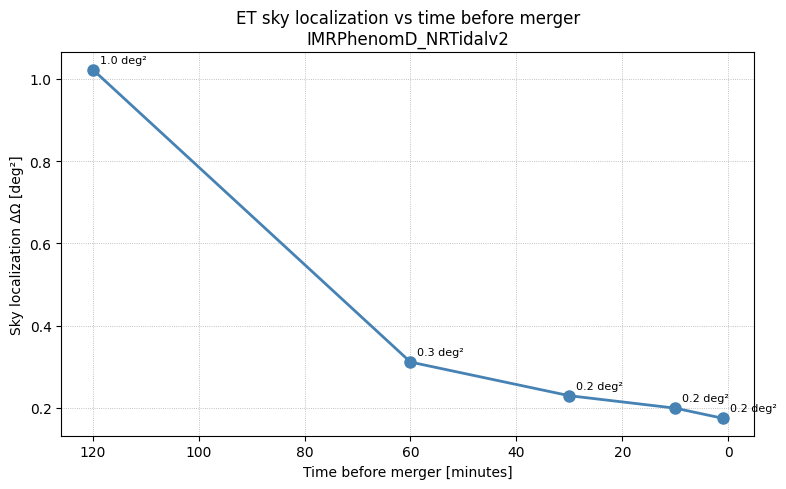

In [21]:
import GWFish.modules as gw
import numpy as np
import matplotlib.pyplot as plt

# ── Fresh network ─────────────────────────────────────────────────────────────
network        = gw.detection.Network(detector_ids=['ET'], detection_SNR=(0., 8.))
original_freqs = network.detectors[0].frequencyvector.copy()
print(f"Original: {original_freqs[0,0]:.2f} → {original_freqs[-1,0]:.2f} Hz, {len(original_freqs)} pts")

Mc_sec     = parameters['chirp_mass'].iloc[0] * 1.989e30 * 6.674e-11 / (3e8)**3
sr_to_deg2 = (180/np.pi)**2

tau_minutes_list = [1, 10, 30, 60, 120]  # ascending: closer → farther
sky_loc_list     = []
f_cut_list       = []

from astropy.constants import G, c, M_sun

Mc_det_kg = float(parameters['chirp_mass'].iloc[0]) * M_sun.value
Mc_sec    = Mc_det_kg * G.value / c.value**3   # detector-frame, seconds

# NOTE: parameters fixed at GW170817 (dL≈40 Mpc). Only f_cut changes per iteration.
for tau_min in tau_minutes_list:
    tau_sec   = tau_min * 60.0
    f_max_cut = (1/np.pi) * (5 / (256 * Mc_sec**(5/3) * tau_sec))**(3/8)
    freq_mask = original_freqs[:, 0] <= f_max_cut
    n_points  = freq_mask.sum()

    network.detectors[0].frequencyvector = original_freqs[freq_mask]
    print(f"tau={tau_min:4d} min → f_cut={f_max_cut:.2f} Hz ({n_points} pts)", end='')

    if n_points < 5:
        print(" → skipped")
        sky_loc_list.append(np.nan)
        f_cut_list.append(f_max_cut)
        network.detectors[0].frequencyvector = original_freqs
        continue

    detected, snr, errors_cut, sky_cut = gw.fishermatrix.compute_network_errors(
        network, parameters,         # fixed GW170817 parameters — intentional
        waveform_model=waveform_model,
        f_ref=f_ref,                 # no redefine_tf_vectors — use our masked vector
    )
    sky_deg2 = float(sky_cut[0]) * sr_to_deg2
    sky_loc_list.append(sky_deg2)
    f_cut_list.append(f_max_cut)
    print(f" → ΔΩ = {sky_deg2:.2f} deg²")

    network.detectors[0].frequencyvector = original_freqs

network.detectors[0].frequencyvector = original_freqs      # final restore
sky_loc_list = np.array(sky_loc_list)
f_cut_list   = np.array(f_cut_list)

# ── Plot ──────────────────────────────────────────────────────────────────────
valid = ~np.isnan(sky_loc_list)
plt.figure(figsize=(8, 5))
plt.plot(np.array(tau_minutes_list)[valid], sky_loc_list[valid],
         'o-', color='steelblue', lw=2, markersize=8)
for tau_min, sky in zip(np.array(tau_minutes_list)[valid], sky_loc_list[valid]):
    plt.annotate(f'{sky:.1f} deg²', (tau_min, sky),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
plt.xlabel('Time before merger [minutes]')
plt.ylabel('Sky localization ΔΩ [deg²]')
plt.title(f'ET sky localization vs time before merger\n{waveform_model}')
plt.grid(linestyle='dotted', linewidth=0.6)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()


z=0.0098  dL=44 Mpc


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.64s/it]


  Full band (merger): ΔΩ = 0.16 deg²


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.17s/it]


  tau=   1 min → f_cut=29.10 Hz → ΔΩ=0.17 deg²


...

  tau=  10 min → f_cut=8.00 Hz → ΔΩ=12146.42 deg²


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.50s/it]


  tau=  30 min → f_cut=5.30 Hz → ΔΩ=16610.49 deg²


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.37s/it]


  tau=  60 min → f_cut=4.09 Hz → ΔΩ=19823.70 deg²


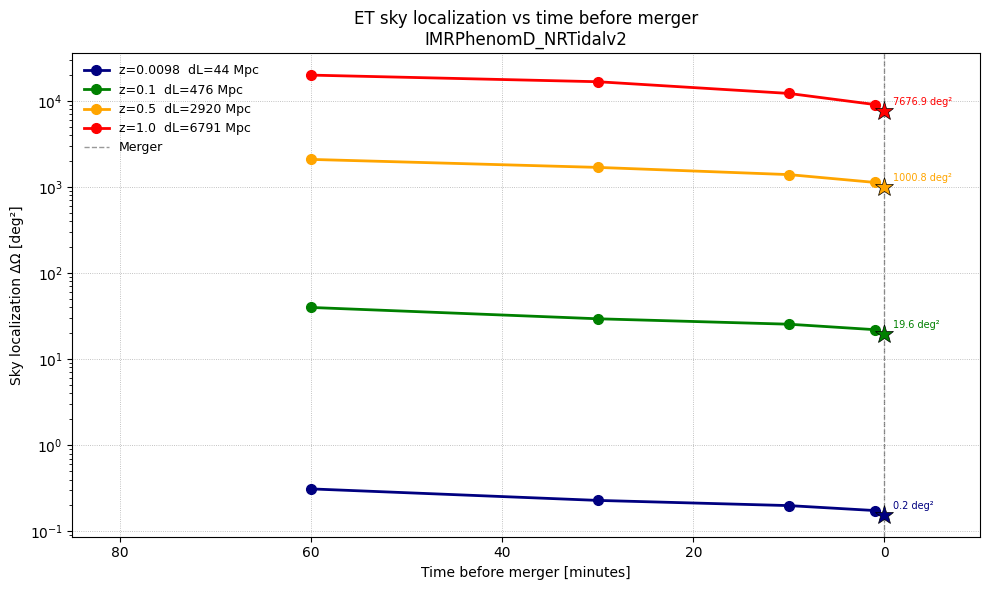

In [22]:
from astropy.cosmology import Planck18
import GWFish.modules as gw
import numpy as np
import matplotlib.pyplot as plt

z_list       = [0.0098, 0.1, 0.5, 1.0]
colors_z     = ['navy', 'green', 'orange', 'red']
Mc_intrinsic = 1.1859
tau_minutes_list = [1, 10, 30, 60]
sr_to_deg2   = (180/np.pi)**2
M_sun = 1.989e30; G = 6.674e-11; c = 3e8

fig, ax = plt.subplots(figsize=(10, 6))

for z, col in zip(z_list, colors_z):
    Mc_det   = Mc_intrinsic * (1 + z)
    dL       = Planck18.luminosity_distance(z).value
    params_z = parameters.copy()
    params_z['chirp_mass']          = Mc_det
    params_z['luminosity_distance'] = dL
    print(f"\nz={z}  dL={dL:.0f} Mpc")

    Mc_sec = Mc_det * M_sun * G / c**3

    # ── Full-band Fisher (at merger) ──────────────────────────────────────────
    network_full   = gw.detection.Network(detector_ids=['ET'], detection_SNR=(0., 8.))
    original_freqs = network_full.detectors[0].frequencyvector.copy()

    detected, snr, errors_full, sky_full = gw.fishermatrix.compute_network_errors(
        network_full, params_z, waveform_model=waveform_model,
        f_ref=f_ref, redefine_tf_vectors=True,
    )
    sky_merger = sky_full[0] * sr_to_deg2
    print(f"  Full band (merger): ΔΩ = {sky_merger:.2f} deg²")

    # ── Pre-merger Fisher loop ────────────────────────────────────────────────
    sky_loc_list = []

    for tau_min in tau_minutes_list:
        tau_sec   = tau_min * 60
        f_max_cut = (1/np.pi) * (5 / (256 * Mc_sec**(5/3) * tau_sec))**(3/8)
        freq_mask = original_freqs[:, 0] <= f_max_cut
        n_points  = freq_mask.sum()

        if n_points < 5:
            sky_loc_list.append(np.nan)
            continue

        network_full.detectors[0].frequencyvector = original_freqs[freq_mask]

        detected, snr, errors_cut, sky_cut = gw.fishermatrix.compute_network_errors(
            network_full, params_z, waveform_model=waveform_model,
            f_ref=f_ref, redefine_tf_vectors=True,
        )
        sky_loc_list.append(sky_cut[0] * sr_to_deg2)
        print(f"  tau={tau_min:4d} min → f_cut={f_max_cut:.2f} Hz "
              f"→ ΔΩ={sky_cut[0]*sr_to_deg2:.2f} deg²")

        network_full.detectors[0].frequencyvector = original_freqs  # restore

    network_full.detectors[0].frequencyvector = original_freqs      # final restore

    sky_loc_list = np.array(sky_loc_list)
    valid        = ~np.isnan(sky_loc_list)
    tau_arr      = np.array(tau_minutes_list)

    # ── Plot pre-merger curve ─────────────────────────────────────────────────
    ax.plot(tau_arr[valid], sky_loc_list[valid],
            'o-', color=col, lw=2, markersize=7,
            label=f'z={z}  dL={dL:.0f} Mpc')

    # ── Plot merger point at tau=0 ────────────────────────────────────────────
    ax.plot(0, sky_merger, '*', color=col, markersize=14,
            markeredgecolor='black', markeredgewidth=0.5, zorder=6)

    # Dashed line connecting last pre-merger point to merger star
    if valid.any():
        ax.plot([tau_arr[valid][0], 0],
                [sky_loc_list[valid][0], sky_merger],
                '--', color=col, lw=1, alpha=0.5)

    # Annotate merger value
    ax.annotate(f'{sky_merger:.1f} deg²', (0, sky_merger),
                textcoords='offset points', xytext=(6, 4),
                fontsize=7, color=col)

# ── Merger reference line ─────────────────────────────────────────────────────
ax.axvline(0, color='black', linestyle='--', lw=1, alpha=0.4, label='Merger')
ax.set_xlabel('Time before merger [minutes]')
ax.set_ylabel('Sky localization ΔΩ [deg²]')
ax.set_title(f'ET sky localization vs time before merger\n{waveform_model}')
ax.grid(linestyle='dotted', linewidth=0.6)
ax.invert_xaxis()   # merger at right (τ=0)
ax.set_xlim(max(tau_minutes_list) + 5, -5)
ax.legend(fontsize=9, frameon=False)
plt.yscale("log")
plt.xlim(85, -10)
plt.tight_layout()
plt.savefig('ET_skyloc_vs_redshift.png', dpi=150, bbox_inches='tight')
plt.show()


z=0.0098  dL=44 Mpc


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.64s/it]


  Full band (merger): SNR = 645.0


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.06s/it]


  tau=   1 min → f_cut=29.10 Hz → SNR=478.3


...

  tau=   5 min → f_cut=10.38 Hz → SNR=3.2


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.31s/it]


  tau=  30 min → f_cut=5.30 Hz → SNR=1.0


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.39s/it]


  tau=  60 min → f_cut=4.09 Hz → SNR=0.5


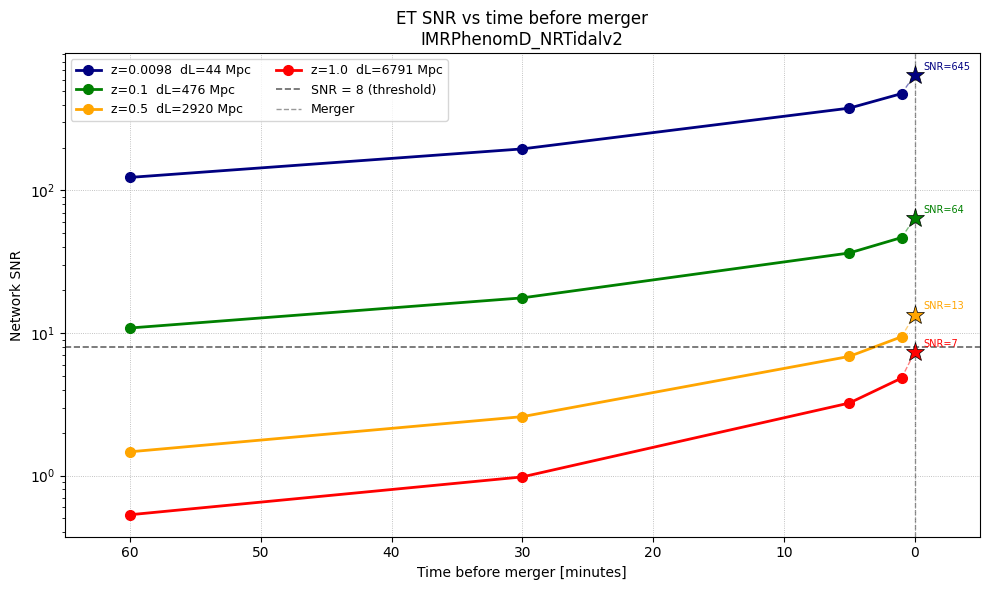

In [23]:
from astropy.cosmology import Planck18
import GWFish.modules as gw
import numpy as np
import matplotlib.pyplot as plt

z_list       = [0.0098, 0.1, 0.5, 1.0]
colors_z     = ['navy', 'green', 'orange', 'red']
Mc_intrinsic = 1.1859
tau_minutes_list = [1, 5, 30, 60]
sr_to_deg2   = (180/np.pi)**2
M_sun = 1.989e30; G = 6.674e-11; c = 3e8

fig, ax = plt.subplots(figsize=(10, 6))

for z, col in zip(z_list, colors_z):
    Mc_det   = Mc_intrinsic * (1 + z)
    dL       = Planck18.luminosity_distance(z).value
    params_z = parameters.copy()
    params_z['chirp_mass']          = Mc_det
    params_z['luminosity_distance'] = dL
    print(f"\nz={z}  dL={dL:.0f} Mpc")

    Mc_sec = Mc_det * M_sun * G / c**3

    # ── Full-band SNR (at merger) ─────────────────────────────────────────────
    network_full   = gw.detection.Network(detector_ids=['ET'], detection_SNR=(0., 8.))
    original_freqs = network_full.detectors[0].frequencyvector.copy()

    detected, snr_full, errors_full, sky_full = gw.fishermatrix.compute_network_errors(
        network_full, params_z, waveform_model=waveform_model,
        f_ref=f_ref, redefine_tf_vectors=True,
    )
    snr_merger = snr_full[0]
    print(f"  Full band (merger): SNR = {snr_merger:.1f}")

    # ── Pre-merger SNR loop ───────────────────────────────────────────────────
    snr_list = []

    for tau_min in tau_minutes_list:
        tau_sec   = tau_min * 60
        f_max_cut = (1/np.pi) * (5 / (256 * Mc_sec**(5/3) * tau_sec))**(3/8)
        freq_mask = original_freqs[:, 0] <= f_max_cut
        n_points  = freq_mask.sum()

        if n_points < 5:
            snr_list.append(np.nan)
            continue

        network_full.detectors[0].frequencyvector = original_freqs[freq_mask]

        detected, snr_cut, errors_cut, sky_cut = gw.fishermatrix.compute_network_errors(
            network_full, params_z, waveform_model=waveform_model,
            f_ref=f_ref, redefine_tf_vectors=True,
        )
        snr_list.append(snr_cut[0])
        print(f"  tau={tau_min:4d} min → f_cut={f_max_cut:.2f} Hz "
              f"→ SNR={snr_cut[0]:.1f}")

        network_full.detectors[0].frequencyvector = original_freqs  # restore

    network_full.detectors[0].frequencyvector = original_freqs      # final restore

    snr_list = np.array(snr_list)
    valid    = ~np.isnan(snr_list)
    tau_arr  = np.array(tau_minutes_list)

    # ── Plot pre-merger SNR curve ─────────────────────────────────────────────
    ax.plot(tau_arr[valid], snr_list[valid],
            'o-', color=col, lw=2, markersize=7,
            label=f'z={z}  dL={dL:.0f} Mpc')

    # ── Plot merger SNR as star at tau=0 ──────────────────────────────────────
    ax.plot(0, snr_merger, '*', color=col, markersize=14,
            markeredgecolor='black', markeredgewidth=0.5, zorder=6)

    # Dashed line to merger
    if valid.any():
        ax.plot([tau_arr[valid][0], 0],
                [snr_list[valid][0], snr_merger],
                '--', color=col, lw=1, alpha=0.5)

    ax.annotate(f'SNR={snr_merger:.0f}', (0, snr_merger),
                textcoords='offset points', xytext=(6, 4),
                fontsize=7, color=col)

# ── Detection threshold ───────────────────────────────────────────────────────
ax.axhline(8, color='black', linestyle='--', lw=1.2, alpha=0.6, label='SNR = 8 (threshold)')
ax.axvline(0, color='black', linestyle='--', lw=1, alpha=0.4, label='Merger')

ax.set_xlabel('Time before merger [minutes]')
ax.set_ylabel('Network SNR')
ax.set_title(f'ET SNR vs time before merger\n{waveform_model}')
ax.grid(linestyle='dotted', linewidth=0.6)
ax.invert_xaxis()   # merger at right
ax.set_xlim(max(tau_minutes_list) + 5, -5)
ax.legend(fontsize=9, ncol=2)
plt.yscale("log")
plt.tight_layout()
plt.savefig('ET_SNR_vs_redshift.png', dpi=150, bbox_inches='tight')
plt.show()

Mc_intrinsic = 1.185900 Msun
ET freq range: 2.00 → 2048.00 Hz  (1000 pts)


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.60s/it]


z=0.007  dL=31 Mpc  SNR=902.8


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.22s/it]


z=0.008  dL=37 Mpc  SNR=762.9


...

z=3.570  dL=32024 Mpc  SNR=3.0


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.83s/it]


z=4.225  dL=39106 Mpc  SNR=2.8


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.23s/it]


z=5.000  dL=47678 Mpc  SNR=2.5

ET horizon:
  z  = 0.904
  dL = 6001 Mpc = 6.00 Gpc


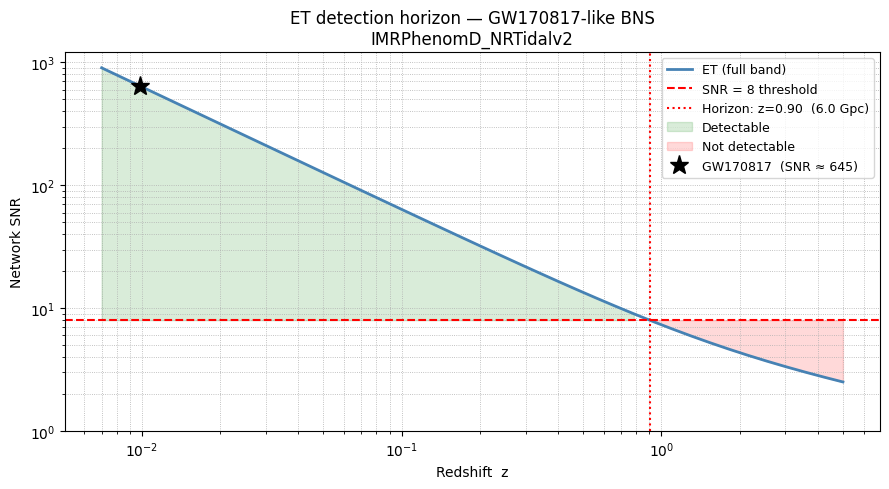

In [24]:
from astropy.cosmology import Planck18
from astropy.constants import G, c, M_sun
import GWFish.modules as gw
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ── Constants (astropy — high precision SI) ───────────────────────────────────
G_val    = G.value        # 6.6743e-11 m³/kg/s²
c_val    = c.value        # 2.99792458e8 m/s
Msun_val = M_sun.value    # 1.988416e30 kg

# ── Source-frame parameters ───────────────────────────────────────────────────
Mc_intrinsic = parameters['chirp_mass'].iloc[0] / (1 + 0.00980)  # source-frame
q            = float(parameters['mass_ratio'].iloc[0])
print(f"Mc_intrinsic = {Mc_intrinsic:.6f} Msun")

# ── Build network ONCE ────────────────────────────────────────────────────────
network_et     = gw.detection.Network(detector_ids=['ET'], detection_SNR=(0., 8.))
original_freqs = network_et.detectors[0].frequencyvector.copy()
print(f"ET freq range: {original_freqs[0,0]:.2f} → {original_freqs[-1,0]:.2f} Hz  "
      f"({len(original_freqs)} pts)")

# ── Redshift grid ─────────────────────────────────────────────────────────────
z_grid   = np.logspace(np.log10(0.007), np.log10(5.0), 40)
snr_grid = []

for z in z_grid:
    Mc_det = Mc_intrinsic * (1 + z)
    dL     = Planck18.luminosity_distance(z).value

    params_z = parameters.copy()
    params_z['chirp_mass']          = Mc_det
    params_z['luminosity_distance'] = dL

    # ✅ Always restore full frequency vector
    network_et.detectors[0].frequencyvector = original_freqs

    _, snr_z, _, _ = gw.fishermatrix.compute_network_errors(
        network_et, params_z,
        waveform_model=waveform_model,
        f_ref=f_ref,
        redefine_tf_vectors=True,
    )
    snr_val = float(snr_z[0])
    snr_grid.append(snr_val)
    print(f"z={z:.3f}  dL={dL:.0f} Mpc  SNR={snr_val:.1f}")

# ✅ Restore at end
network_et.detectors[0].frequencyvector = original_freqs

snr_grid = np.array(snr_grid)
dL_grid  = np.array([Planck18.luminosity_distance(z).value for z in z_grid])

# ── Find horizon ──────────────────────────────────────────────────────────────
valid = ~np.isnan(snr_grid)
if (snr_grid[valid] >= 8).any() and (snr_grid[valid] < 8).any():
    z_horizon  = float(interp1d(snr_grid[valid][::-1], z_grid[valid][::-1])(8.0))
    dL_horizon = float(interp1d(snr_grid[valid][::-1], dL_grid[valid][::-1])(8.0))
    print(f"\nET horizon:")
    print(f"  z  = {z_horizon:.3f}")
    print(f"  dL = {dL_horizon:.0f} Mpc = {dL_horizon/1e3:.2f} Gpc")
else:
    raise ValueError("SNR=8 not crossed — extend z_grid!")

# ── GW170817 reference point ──────────────────────────────────────────────────
snr_170817 = float(interp1d(z_grid[valid], snr_grid[valid])(0.0098))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(z_grid[valid], snr_grid[valid],
          color='steelblue', lw=2, label='ET (full band)')
ax.axhline(8, color='red', linestyle='--', lw=1.5, label='SNR = 8 threshold')
ax.axvline(z_horizon, color='red', linestyle=':', lw=1.5,
           label=f'Horizon: z={z_horizon:.2f}  ({dL_horizon/1e3:.1f} Gpc)')
ax.fill_between(z_grid[valid], snr_grid[valid], 8,
                where=snr_grid[valid] >= 8,
                alpha=0.15, color='green', label='Detectable')
ax.fill_between(z_grid[valid], snr_grid[valid], 8,
                where=snr_grid[valid] < 8,
                alpha=0.15, color='red', label='Not detectable')
ax.plot(0.0098, snr_170817, 'k*', markersize=14, zorder=5,
        label=f'GW170817  (SNR ≈ {snr_170817:.0f})')
ax.set_xlabel('Redshift  z')
ax.set_ylabel('Network SNR')
ax.set_title(f'ET detection horizon — GW170817-like BNS\n{waveform_model}')
ax.legend(fontsize=9)
ax.grid(linestyle='dotted', linewidth=0.6, which='both')
ax.set_ylim(1, None)
plt.tight_layout()
plt.savefig('ET_horizon_BNS.png', dpi=150, bbox_inches='tight')
plt.show()

## SNR² per Hz — Physical Interpretation

The matched filter SNR is defined as:

$$\rho^2 = 4 \int_0^\infty \frac{|\tilde{h}(f)|^2}{S_n(f)} \, df$$

So **SNR² per Hz** is the integrand:

$$\frac{d\rho^2}{df} = 4 \frac{|\tilde{h}(f)|^2}{S_n(f)}$$

It tells you **which frequencies contribute most** to the total SNR:

- **High** $d\rho^2/df$ → signal is loud compared to noise → frequency band is very useful
- **Low** $d\rho^2/df$ → signal is weak or noise is high → frequency contributes little

It is a competition between two effects:

| Factor | Behaviour |
|---|---|
| $|\tilde{h}(f)|^2$ | Decreases at high $f$ — inspiral signal weakens as it sweeps up |
| $S_n(f)$ | ET noise is lowest around 10–100 Hz (the "sweet spot") |

The **peak** of $d\rho^2/df$ tells you ET's most sensitive frequency for this source.

A more intuitive quantity is the **SNR² per frequency decade**:

$$f \cdot \frac{d\rho^2}{df}$$

which answers: *"if I could only observe one frequency decade, which would give me the most SNR?"*

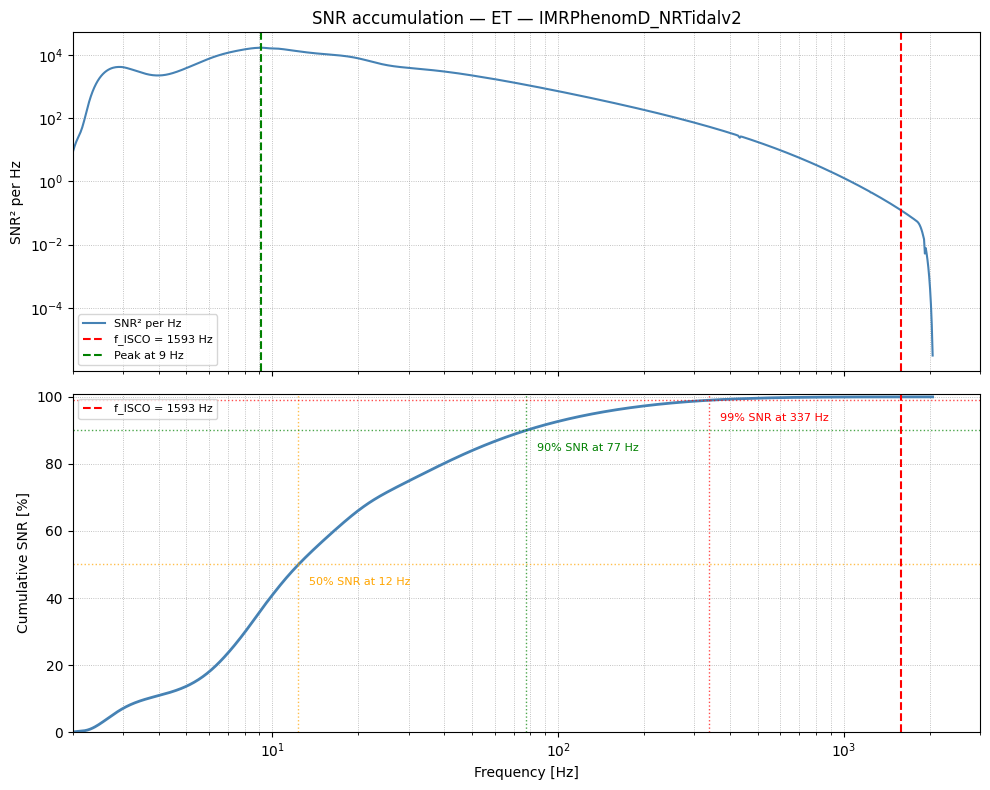

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import GWFish.modules as gw
from scipy.interpolate import interp1d

# ── Recompute everything from scratch ─────────────────────────────────────────
network_check  = gw.detection.Network(detector_ids=['ET'], detection_SNR=(0., 8.))
frequency_full = network_check.detectors[0].frequencyvector[:, 0]

signal_check, _ = gw.utilities.get_fd_signal(parameters, 'ET', waveform_model, f_ref)
psd_ET_check    = gw.utilities.get_detector_psd('ET')

# Interpolate PSD onto signal frequency grid
Sn = interp1d(psd_ET_check[:, 0], psd_ET_check[:, 1],
              bounds_error=False, fill_value=np.inf)(frequency_full)

# Cumulative SNR
signal_combined = np.sqrt(np.sum(np.abs(signal_check)**2, axis=1))
df              = np.diff(frequency_full)
df              = np.append(df, df[-1])
snr2_integrand  = 4 * signal_combined**2 / Sn * df
snr2_cumulative = np.cumsum(snr2_integrand)
snr_cumulative  = np.sqrt(snr2_cumulative)
snr_total       = snr_cumulative[-1]

# ISCO frequency
q      = parameters['mass_ratio'].iloc[0]
Mc_det = parameters['chirp_mass'].iloc[0]
m1     = Mc_det * (1 + q)**(1/5) / q**(3/5)
m2     = q * m1
M_tot  = (m1 + m2) * 1.989e30
f_isco = (3e8)**3 / (6**1.5 * np.pi * 6.674e-11 * M_tot)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# SNR² per Hz
ax1.loglog(frequency_full, snr2_integrand/df,
           color='steelblue', lw=1.5, label='SNR² per Hz')
ax1.axvline(f_isco, color='red', linestyle='--', lw=1.5,
            label=f'f_ISCO = {f_isco:.0f} Hz')
f_peak = frequency_full[np.argmax(snr2_integrand/df)]
ax1.axvline(f_peak, color='green', linestyle='--', lw=1.5,
            label=f'Peak at {f_peak:.0f} Hz')
ax1.set_ylabel('SNR² per Hz')
ax1.legend(fontsize=8)
ax1.grid(linestyle='dotted', linewidth=0.6, which='both')
ax1.set_title(f'SNR accumulation — ET — {waveform_model}')

# Cumulative SNR %
ax2.semilogx(frequency_full, snr_cumulative/snr_total*100,
             color='steelblue', lw=2)
for pct, col in [(50, 'orange'), (90, 'green'), (99, 'red')]:
    idx   = np.argmin(np.abs(snr_cumulative/snr_total*100 - pct))
    f_pct = frequency_full[idx]
    ax2.axhline(pct, color=col, linestyle=':', lw=1, alpha=0.7)
    ax2.axvline(f_pct, color=col, linestyle=':', lw=1, alpha=0.7)
    ax2.annotate(f'{pct}% SNR at {f_pct:.0f} Hz',
                 (f_pct, pct), textcoords='offset points',
                 xytext=(8, -15), fontsize=8, color=col)

ax2.axvline(f_isco, color='red', linestyle='--', lw=1.5,
            label=f'f_ISCO = {f_isco:.0f} Hz')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Cumulative SNR [%]')
ax2.set_xlim(2, 3000)
ax2.set_ylim(0, 101)
ax2.grid(linestyle='dotted', linewidth=0.6, which='both')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('SNR_accumulation_ET.png', dpi=150, bbox_inches='tight')
plt.show()

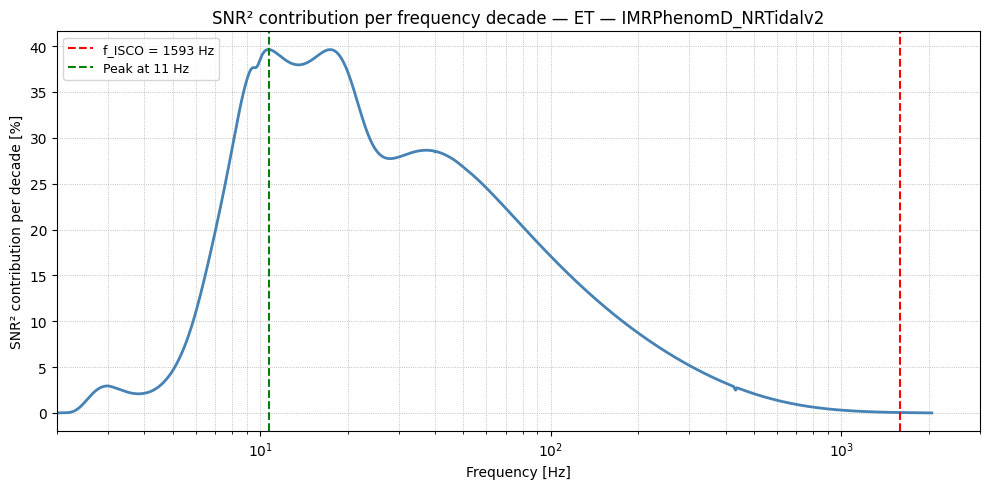

In [26]:
# SNR per decade = f * d(SNR²)/df  (weighted by frequency)
fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogx(frequency_full, 
            frequency_full * snr2_integrand/df / snr_total**2 * 100,
            color='steelblue', lw=2)
ax.axvline(f_isco, color='red', linestyle='--', lw=1.5,
           label=f'f_ISCO = {f_isco:.0f} Hz')
f_peak = frequency_full[np.argmax(frequency_full * snr2_integrand/df)]
ax.axvline(f_peak, color='green', linestyle='--', lw=1.5,
           label=f'Peak at {f_peak:.0f} Hz')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('SNR² contribution per decade [%]')
ax.set_title(f'SNR² contribution per frequency decade — ET — {waveform_model}')
ax.legend(fontsize=9)
ax.grid(linestyle='dotted', linewidth=0.6, which='both')
ax.set_xlim(2, 3000)
plt.tight_layout()
plt.show()